# 05 Tongue Crop Library

This notebook shows the Tongue River crop curve library — representative
NDVI phenology for five crop types, built from 55,451 field-year Landsat
profiles filtered by USDA Cropland Data Layer labels.

Full workflow context:
[Tongue Scenario Analysis](../workflows/tongue-scenario-analysis.md)

Artifact read here: `tongue_crop_library.json`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from swim_mtdnrc.clustering.crop_library import load_crop_library
from swim_mtdnrc.clustering.cdl_crosstab import CDL_NAMES

LIB_PATH = "/nas/swim/examples/tongue/data/crop_library/tongue_crop_library.json"
library = load_crop_library(LIB_PATH)
print(f"{len(library)} crop groups loaded")

5 crop groups loaded


In [2]:
rows = []
for crop_name, entry in sorted(library.items()):
    pheno = entry["phenology"]
    cdl_labels = ", ".join(CDL_NAMES.get(c, str(c)) for c in entry["cdl_codes"])
    # Perennial crops (alfalfa, grass, hay) don't senesce below the
    # NDVI threshold within the growing season, so season_length is None.
    sl = pheno["season_length"]
    rows.append({
        "Crop": crop_name,
        "CDL Labels": cdl_labels,
        "Profiles": entry["n_profiles"],
        "Peak NDVI": round(pheno["peak_ndvi"], 3),
        "Peak DOY": int(pheno["peak_doy"]),
        "Greenup DOY": int(pheno["greenup_doy"]),
        "Season": f"{int(sl)} days" if sl else "perennial",
    })

summary = pd.DataFrame(rows).set_index("Crop")
summary

,CDL Labels,Profiles,Peak NDVI,Peak DOY,Greenup DOY,Season
Crop,,,,,,
alfalfa,Alfalfa,8489,0.637,156,105,perennial
corn,Corn,507,0.718,225,172,103 days
grass_pasture,"Grassland/Pasture, Grassland/Pasture",5805,0.680,173,99,perennial
other_hay,Other Hay,4421,0.709,165,94,perennial
small_grains,"Barley, Spring Wheat, Winter Wheat, Other Sm G...",413,0.614,179,143,87 days


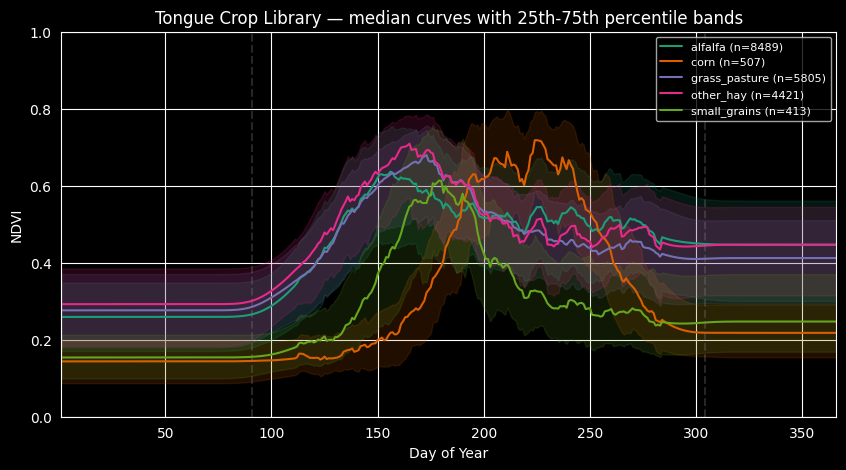

In [3]:
doys = np.arange(1, 367)
colors = {"alfalfa": "#1b9e77", "corn": "#d95f02", "grass_pasture": "#7570b3",
          "other_hay": "#e7298a", "small_grains": "#66a61e"}

fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111)

for crop_name in sorted(library):
    entry = library[crop_name]
    c = colors.get(crop_name, "gray")
    ax.plot(doys, entry["curve_366"],
            label=f"{crop_name} (n={entry['n_profiles']})", color=c)
    ax.fill_between(doys, entry["p25_366"], entry["p75_366"],
                    alpha=0.15, color=c)

ax.axvline(91, color="gray", ls="--", alpha=0.3)
ax.axvline(304, color="gray", ls="--", alpha=0.3)
ax.set_xlabel("Day of Year")
ax.set_ylabel("NDVI")
ax.set_title("Tongue Crop Library — median curves with 25th-75th percentile bands")
ax.set_xlim(1, 366)
ax.set_ylim(0, 1)
ax.legend(loc="upper right", fontsize=8)
plt.show()

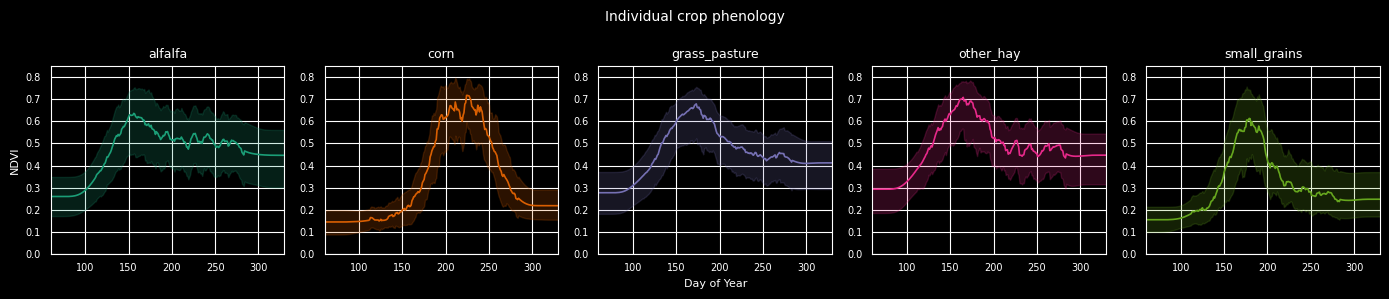

In [4]:
crop_names = sorted(library)
fig = plt.figure(figsize=(14, 3))

for i, crop_name in enumerate(crop_names):
    ax = fig.add_subplot(1, len(crop_names), i + 1)
    entry = library[crop_name]
    c = colors.get(crop_name, "gray")
    ax.plot(doys, entry["curve_366"], color=c, linewidth=1.2)
    ax.fill_between(doys, entry["p25_366"], entry["p75_366"],
                    alpha=0.2, color=c)
    ax.set_title(crop_name, fontsize=9)
    ax.set_xlim(60, 330)
    ax.set_ylim(0, 0.85)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.set_ylabel("NDVI", fontsize=8)
    if i == len(crop_names) // 2:
        ax.set_xlabel("Day of Year", fontsize=8)

fig.suptitle("Individual crop phenology", fontsize=10)
fig.tight_layout()
plt.show()